In [1]:
#| export

import numpy as np
from numba import njit
import numpy.matlib
from jaxcmr.memorysearch import experience, start_retrieving, free_recall, trial_item_count, simulate_trial, retrieve
import jax
from jax import numpy as jnp
from tqdm import trange

@njit(nogil=True)
def find_first(item, vec):
    """return the index of the first occurence of item in vec"""
    for i in range(len(vec)):
        if item == vec[i]:
            return i
    return -1

def simulate_h5_from_h5(
    model_init, # a free recall model
    parameters, # parameters for model initialization. if a list, length must equal number of experiments
    data, # data in EMBAM format 
    trial_mask, # trial-level mask to filter data with before simulation 
    experiment_count=1, # number of simulations to run
    ignore_first_recall=False, # whether to use first recalls from data instead of simulating them
    embedding_list=None, # strings embeddings to use for semantic associations
    # second_string_embeddings=None,
    # switch_query=None
    ):
    """
    Initialize a free recall model with specified parameters and experience sequences from the provided data,
    then simulate recall and populate an EMBAM-formatted data structure with the outcomes of the simulations.

    Returns:
    - A populated EMBAM-formatted data structure with the outcomes of the simulations.

    **Required model class attributes**:
    - item_count: specifies number of items encoded into memory
    - experience: adding a new trace to the memory model
    - free_recall: function that freely recalls a given number of items or until recall stops
    - retrieve: function that forces recall of a given item
    """

    if trial_mask is None:
        trial_mask = np.ones(len(data['recalls']), dtype=np.bool_)

    trial_list_lengths = data['listLength'][trial_mask].flatten()
    list_lengths = np.unique(trial_list_lengths)
    assert(len(list_lengths) == 1)
    list_length = list_lengths[0]
    trials = data['recalls'][trial_mask]
    presentations = data['pres_itemnos'][trial_mask, :list_length]
    rng = jax.random.PRNGKey(0)

    if embedding_list is not None:
        string_ids = data['pres_itemids'][trial_mask, :list_length]

        # for now assume, embedding list is of size 1
        string_embeddings = embedding_list[0]

    simulate_by_subject = isinstance(parameters, list)
    if simulate_by_subject:
        subject_indices = np.unique(data['subject'])
        assert(len(parameters) == len(subject_indices))
    else:
        subject_indices = [0]
        parameters = [parameters]

    # pre-allocate for experiments
    sim_h5 = {}
    for key in data:
        assert(data[key].ndim == 2)
        if key == 'recalls': 
            sim_h5[key] = np.matlib.repmat(np.zeros(np.shape(data['pres_itemnos'][trial_mask]), dtype=np.int64), experiment_count, 1)
        else:
            sim_h5[key] = np.matlib.repmat(data[key][trial_mask], experiment_count, 1)

    total_index = 0
    for experiment in trange(experiment_count):
        for trial_index in range(len(presentations)):
            rng = jax.random.split(rng, 1)[0]

            # identify subject for this trial
            if simulate_by_subject:
                subject = data['subject'][trial_index]
                subject_index = np.where(subject_indices == subject)[0][0]
            else:
                subject_index = 0
            trial_parameters = parameters[subject_index]

            presentation = presentations[trial_index]
            trial = trials[trial_index]
            item_count = np.max(presentation)
            if embedding_list is None:
                trial_items = np.eye(item_count)
            else:
                trial_items = string_embeddings[string_ids[trial_index, :list_length]-1]

            # model = model_class(trial_items, len(presentation), trial_parameters)
            # model.experience(trial_items[presentation-1])
            assert(np.sum(presentation <1) == 0)

            # simulate first item recalled in data if ignore_first_recall
            # if first recall is 0, we immediately terminate recall
            # if ignore_first_recall and trial[0] > 0:
            #     model.retrieve(presentation[trial[0]-1])
            #     recalled = model.free_recall()
            #     trial = np.array([find_first(recalled[i], presentation-1)+1 for i in range(len(recalled))])
            # elif ignore_first_recall and trial[0] == 0: 
            #     trial = np.zeros(1)
            # else:
            #     recalled = model.free_recall()
            #     trial = np.array([find_first(recalled[i], presentation-1)+1 for i in range(len(recalled))])
            
            if ignore_first_recall and trial[0] > 0:
                raise NotImplementedError
                recalled = np.array(simulate_trial(
                    model_init, 
                    item_count, 
                    presentation, 
                    presentation[trial[0]-1], 
                    rng,
                    trial_parameters
                ))
                trial = np.array(
                    [find_first(recalled[i], np.array(presentation)-1)+1 
                     for i in range(len(recalled))])
            elif ignore_first_recall and trial[0] == 0: 
                trial = np.zeros(1)
            else:
                recalled = np.array(simulate_trial(
                    model_init, 
                    item_count.item(), 
                    presentation,
                    rng,
                    trial_parameters['fixed']
                ))
                # trial = np.array([
                #     find_first(recalled[i], np.array(presentation)-1)+1 for i in range(len(recalled))])
                
            sim_h5['recalls'][total_index, :len(trial)] = recalled
            total_index += 1

    return sim_h5

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
from jaxcmr.memorysearch import BaseCMR, InstanceCMR
from jaxcmr.parameters import Parameters, parameter_list
from jaxcmr.analyses import plot_crp, plot_pfr, plot_spc
from jaxcmr.datasets import load_data, generate_trial_mask
import matplotlib.pyplot as plt
import hdf5storage
import os
import json

model_name = 'Base_CMR'
data_tag = 'HealyKahana2014'
trial_query = "data['listtype'] == -1"

analyses = {'CRP': plot_crp, 'PFR': plot_pfr, 'SPC': plot_spc}

# figures_path = "icmr/{}_{}_{}_{}.pdf"
simulation_path = 'D:/data/results/{}_{}_{}.h5'
param_path = 'D:/data/results/{}_{}_{}.jsonl'
data_path = 'D:/data/{}.h5'
    
ignore_first_recall = False
data = load_data(data_path.format(data_tag))
# param_list = parameter_list(param_path.format(model_name, data_tag, ignore_first_recall))

with open(param_path.format(model_name, data_tag, ignore_first_recall)) as f:
    param_list = [json.loads(line) for line in f.readlines()]

list_length = np.unique(data['listLength'])[0]

result = simulate_h5_from_h5(
    BaseCMR.create, #Instance_CMR, #Base_CMR, # a free recall model
    param_list, #parameters.fixed, # parameters for model initialization
    data, # data in EMBAM format 
    generate_trial_mask(data, trial_query), # mask to filter data with before simulation 
    experiment_count=100, # number of simulations to run
    ignore_first_recall=ignore_first_recall, # whether to use first recalls from data instead of simulating them
    embedding_list=None, # strings embeddings to use for semantic associations
)

100%|██████████| 100/100 [07:29<00:00,  4.49s/it]


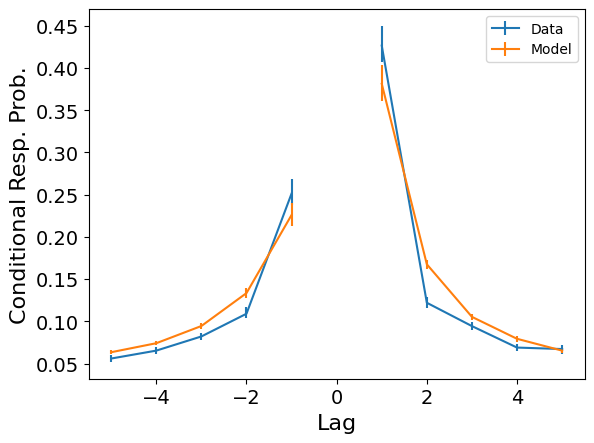

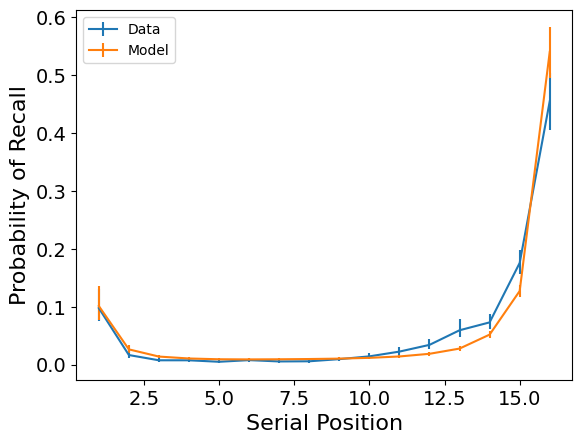

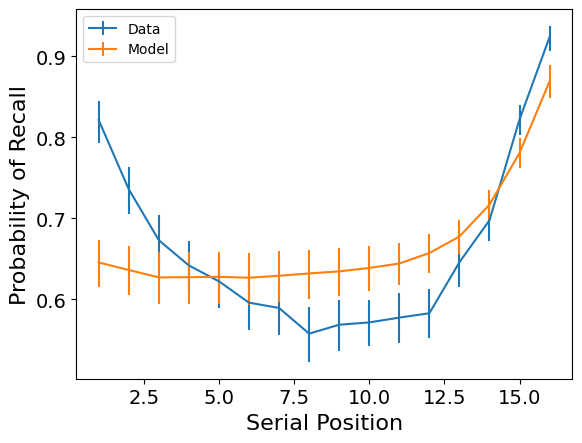

In [3]:
datasets = [data, result]
trial_masks = [ generate_trial_mask(data, trial_query),  generate_trial_mask(result, trial_query)]

for analysis_name in analyses:
    analysis = analyses[analysis_name]

    axis = analysis(datasets, trial_masks, labels=['Data', 'Model'], contrast_name=model_name.replace('_', ' '))
    
    axis.legend(title=None)
    axis.tick_params(labelsize=14)
    axis.set_xlabel(axis.get_xlabel(), fontsize=16)
    axis.set_ylabel(axis.get_ylabel(), fontsize=16)

    plt.show()